
===== KPI SUMMARY =====
Average Transfer Efficiency Ratio: 0.69
Average Discharge Effectiveness: nan
Average Pipeline Throughput: inf
Maximum Backlog: 206.0


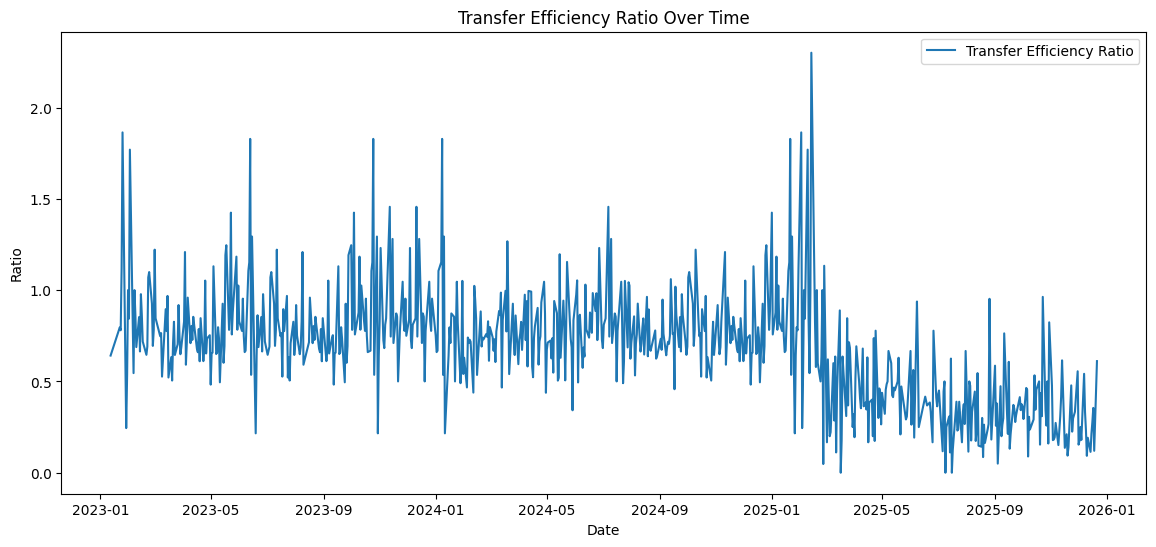

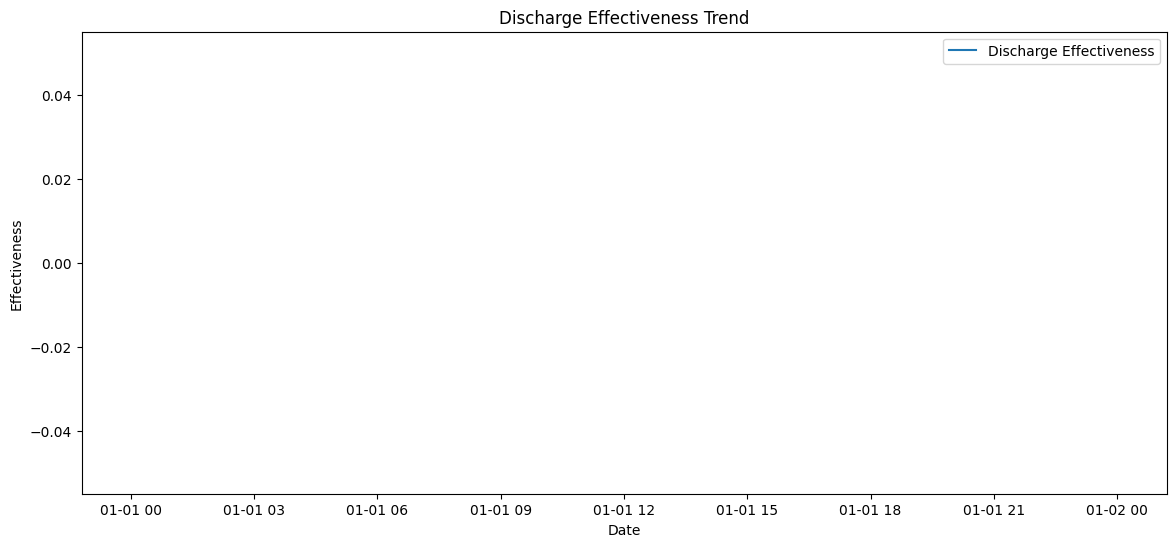

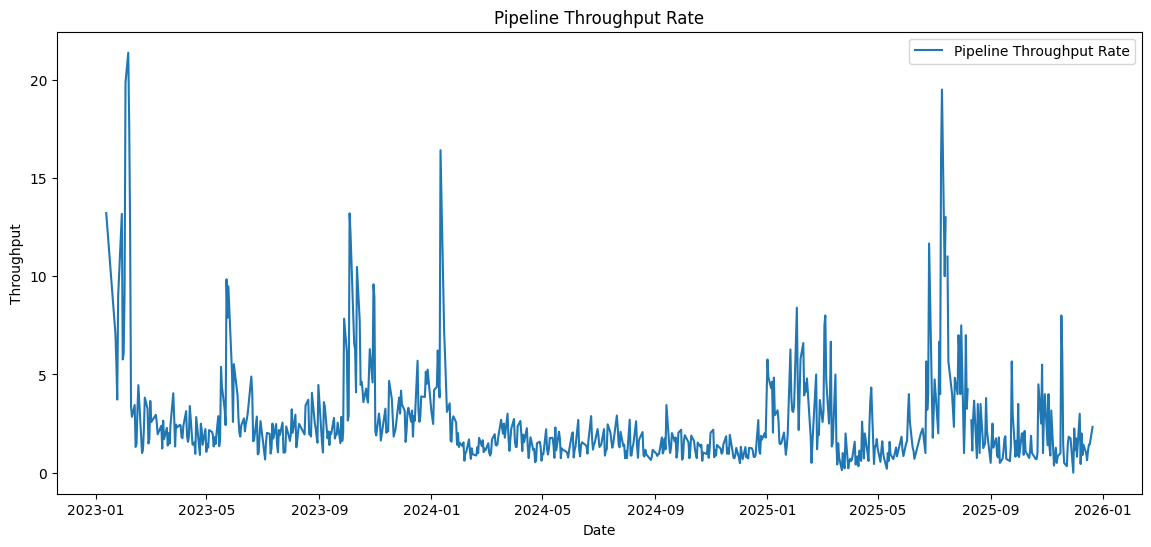

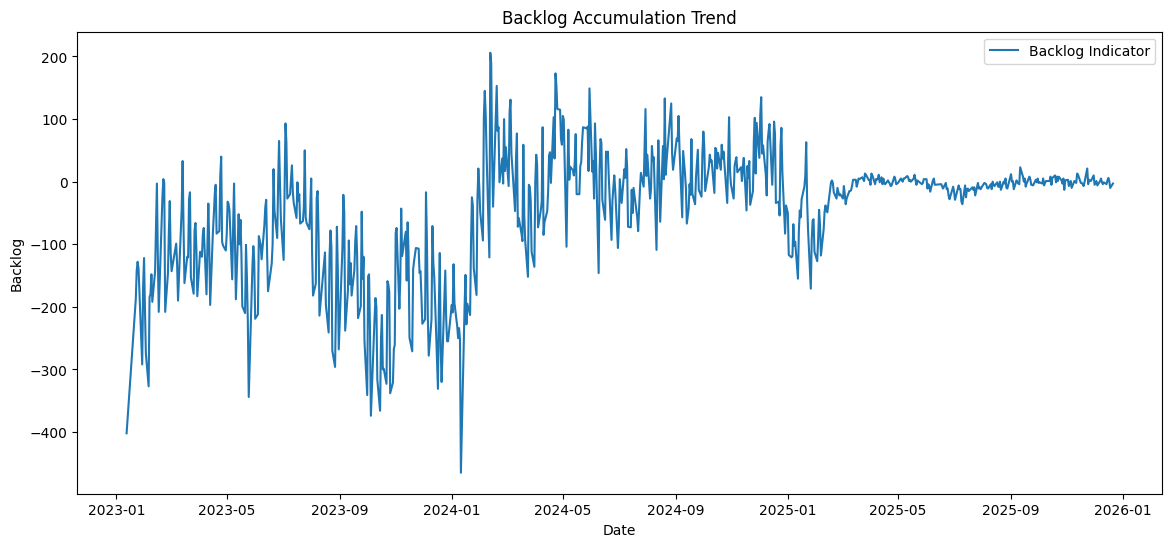

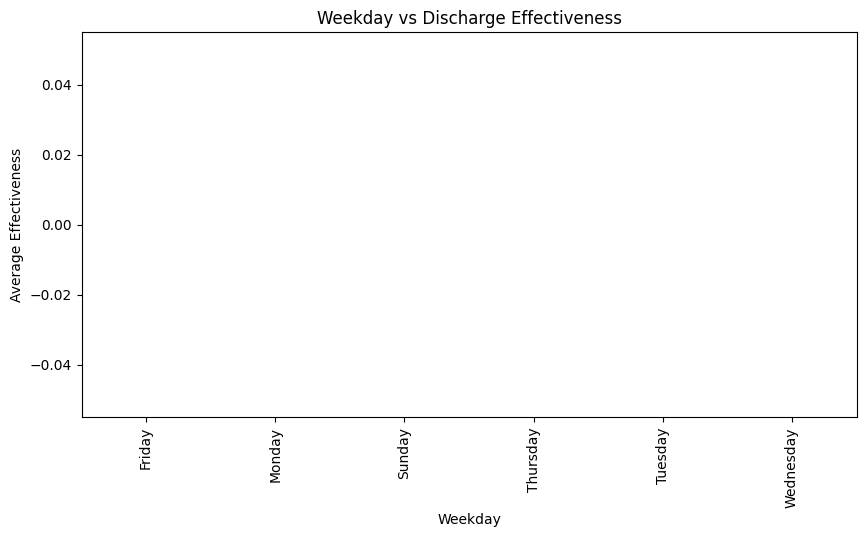


PROJECT EXECUTED SUCCESSFULLY


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('HHS_Unaccompanied_Alien_Children_Program (2).csv')

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values('Date')

# Set index
df.set_index('Date', inplace=True)

# Convert relevant columns to numeric, coercing errors
df['Children transferred out of CBP custody'] = pd.to_numeric(df['Children transferred out of CBP custody'], errors='coerce')
df['Children in CBP custody'] = pd.to_numeric(df['Children in CBP custody'], errors='coerce')
df['Children discharged from HHS Care'] = pd.to_numeric(df['Children discharged from HHS Care'], errors='coerce')
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')
df['Children apprehended and placed in CBP custody*'] = pd.to_numeric(df['Children apprehended and placed in CBP custody*'], errors='coerce')

# ======================================
# PIPELINE METRICS
# ======================================

# Transfer Efficiency Ratio
df['Transfer_Efficiency_Ratio'] = (
    df['Children transferred out of CBP custody'] /
    df['Children in CBP custody']
)

# Discharge Effectiveness
df['Discharge_Effectiveness'] = (
    df['Children discharged from HHS Care'] /
    df['Children in HHS Care']
)

# Pipeline Throughput Rate
df['Pipeline_Throughput_Rate'] = (
    df['Children discharged from HHS Care'] /
    df['Children apprehended and placed in CBP custody*']
)

# Backlog Indicator
df['Backlog_Indicator'] = (
    df['Children transferred out of CBP custody'] -
    df['Children discharged from HHS Care']
)

# Weekday and Month
df['Weekday'] = df.index.day_name()

df['Month'] = df.index.month

# ======================================
# KPI SUMMARY
# ======================================

print("\n===== KPI SUMMARY =====")

print("Average Transfer Efficiency Ratio:",
      round(df['Transfer_Efficiency_Ratio'].mean(),2))

print("Average Discharge Effectiveness:",
      round(df['Discharge_Effectiveness'].mean(),2))

print("Average Pipeline Throughput:",
      round(df['Pipeline_Throughput_Rate'].mean(),2))

print("Maximum Backlog:",
      round(df['Backlog_Indicator'].max(),2))

# ======================================
# PLOT 1
# TRANSFER EFFICIENCY
# ======================================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Transfer_Efficiency_Ratio'],
    label='Transfer Efficiency Ratio'
)

plt.title('Transfer Efficiency Ratio Over Time')

plt.xlabel('Date')
plt.ylabel('Ratio')

plt.legend()

plt.show()

# ======================================
# PLOT 2
# DISCHARGE EFFECTIVENESS
# ======================================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Discharge_Effectiveness'],
    label='Discharge Effectiveness'
)

plt.title('Discharge Effectiveness Trend')

plt.xlabel('Date')
plt.ylabel('Effectiveness')

plt.legend()

plt.show()

# ======================================
# PLOT 3
# PIPELINE THROUGHPUT
# ======================================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Pipeline_Throughput_Rate'],
    label='Pipeline Throughput Rate'
)

plt.title('Pipeline Throughput Rate')

plt.xlabel('Date')
plt.ylabel('Throughput')

plt.legend()

plt.show()

# ======================================
# PLOT 4
# BACKLOG INDICATOR
# ======================================

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Backlog_Indicator'],
    label='Backlog Indicator'
)

plt.title('Backlog Accumulation Trend')

plt.xlabel('Date')
plt.ylabel('Backlog')

plt.legend()

plt.show()

# ======================================
# WEEKDAY ANALYSIS
# ======================================

weekday_avg = df.groupby('Weekday')[
    'Discharge_Effectiveness'
].mean()

plt.figure(figsize=(10,5))

weekday_avg.plot(kind='bar')

plt.title('Weekday vs Discharge Effectiveness')

plt.ylabel('Average Effectiveness')

plt.show()

print("\nPROJECT EXECUTED SUCCESSFULLY")